# Análise de Dados — Cyclistic Bike-Share

**Ferramenta:** Python + DuckDB  
**Fonte dos dados:** Divvy/Lyft — https://divvy-tripdata.s3.amazonaws.com/index.html  
**Licença:** https://divvybikes.com/data-license-agreement

---

## Contexto de Negócio

Analisar os dados históricos de viagens da Divvy no período de abril de 2025 a 
março de 2026 para identificar **diferenças de comportamento entre usuários casuais e membros anuais** — e derivar estratégias de conversão fundamentadas em padrão de uso.

## Perguntas que este notebook responde

1. Em quais dias e horários cada grupo realiza mais viagens?
2. Qual a duração média de viagem de cada grupo?
3. Como o uso varia ao longo das estações do ano?
4. Quais são os locais de partida mais frequentes de cada grupo?
5. Existe diferença na preferência de tipo de bicicleta?

---

In [3]:
import duckdb
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import pandas as pd
import seaborn as sns
import os

con = duckdb.connect('../database/cyclistic_project.duckdb')

#Configuração do estilo dos gráficos que serão utilizados na análise
sns.set_style("whitegrid")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica'],
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'legend.fontsize': 11,
    'figure.dpi': 150
})

COR_CASUAL = '#0072B2'   
COR_MEMBER = '#E69F00'

## Usuário casual vs Membro anual  
Chamamos de usuários casuais aqueles clientes que compram um passe por corrida, ou um passe para o dia todo de corridas.  
Chamamos de membros anuais aqueles clientes que compram assinatura anual.  


---
## 1. Quando cada grupo usa o serviço?
### Dias da semana e horário do dia

O primeiro passo é entender **quando** cada grupo pedala.  
A hipótese inicial é que membros usam o serviço de forma rotineira — com rotas e horários fixos — enquanto casuais usam de forma esporádica, sem uma rotina definida.

### 1.1 Volume de viagens por dia da semana

Referência dos dias: `0 = Domingo | 1 = Segunda | 2 = Terça | 3 = Quarta | 4 = Quinta | 5 = Sexta | 6 = Sábado`

In [4]:
#viagens em cada dia da semana - por grupo
con.execute("""
    SELECT
        member_casual AS "Usuário",
        day_of_week AS "Dia da Semana",
        COUNT(*) AS "Total",
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(PARTITION BY member_casual), 2) AS "% do Grupo"
    FROM cyclistic
    GROUP BY 1, 2
    ORDER BY 1, 2
""").df()

,Usuário,Dia da Semana,Total,% do Grupo
0,casual,0,337297,16.78
1,casual,1,233740,11.63
2,casual,2,227402,11.31
3,casual,3,223847,11.13
4,casual,4,259096,12.89
5,casual,5,314232,15.63
6,casual,6,414920,20.64
7,member,0,387294,10.75
8,member,1,511219,14.19
9,member,2,580773,16.12


---
##### Disclaimer: Nessa query eu vou agrupar os dias da semana em Dia útil e Fim de semana. Como a quantidade de dias de cada grupo será diferente (5 x 2), iremos usar a média, e não a quantidade total.  

In [5]:
#Agrupando por Dia Útil vs Fim de Semana
df_agrupamento = con.execute("""
    WITH Agrupamento AS (
        SELECT 
            member_casual AS "Usuário",
            CASE WHEN day_of_week IN (0, 6) THEN 'Fim de semana'
                 ELSE 'Dia útil' END AS "Período",
            COUNT(*) AS "Volume Absoluto"
        FROM cyclistic
        GROUP BY 1, 2
    )
    SELECT
        "Usuário", "Período",
        ROUND("Volume Absoluto" / CASE WHEN "Período" = 'Fim de semana' THEN 2.0 ELSE 5.0 END, 0) AS "Média de viagens por Dia",
        ROUND(("Volume Absoluto" / CASE WHEN "Período" = 'Fim de semana' THEN 2.0
            ELSE 5.0 END) * 100.0 / SUM("Volume Absoluto" / CASE WHEN "Período" = 'Fim de semana' THEN 2.0
                ELSE 5.0 END) OVER(PARTITION BY "Usuário"), 2) AS "% do Grupo"
    FROM Agrupamento
    ORDER BY 1, 2
""").df()
display(df_agrupamento)

,Usuário,Período,Média de viagens por Dia,% do Grupo
0,casual,Dia útil,251663.0,40.09
1,casual,Fim de semana,376109.0,59.91
2,member,Dia útil,552990.0,56.87
3,member,Fim de semana,419458.0,43.13


---
#### Traduzindo esses números em gráficos:

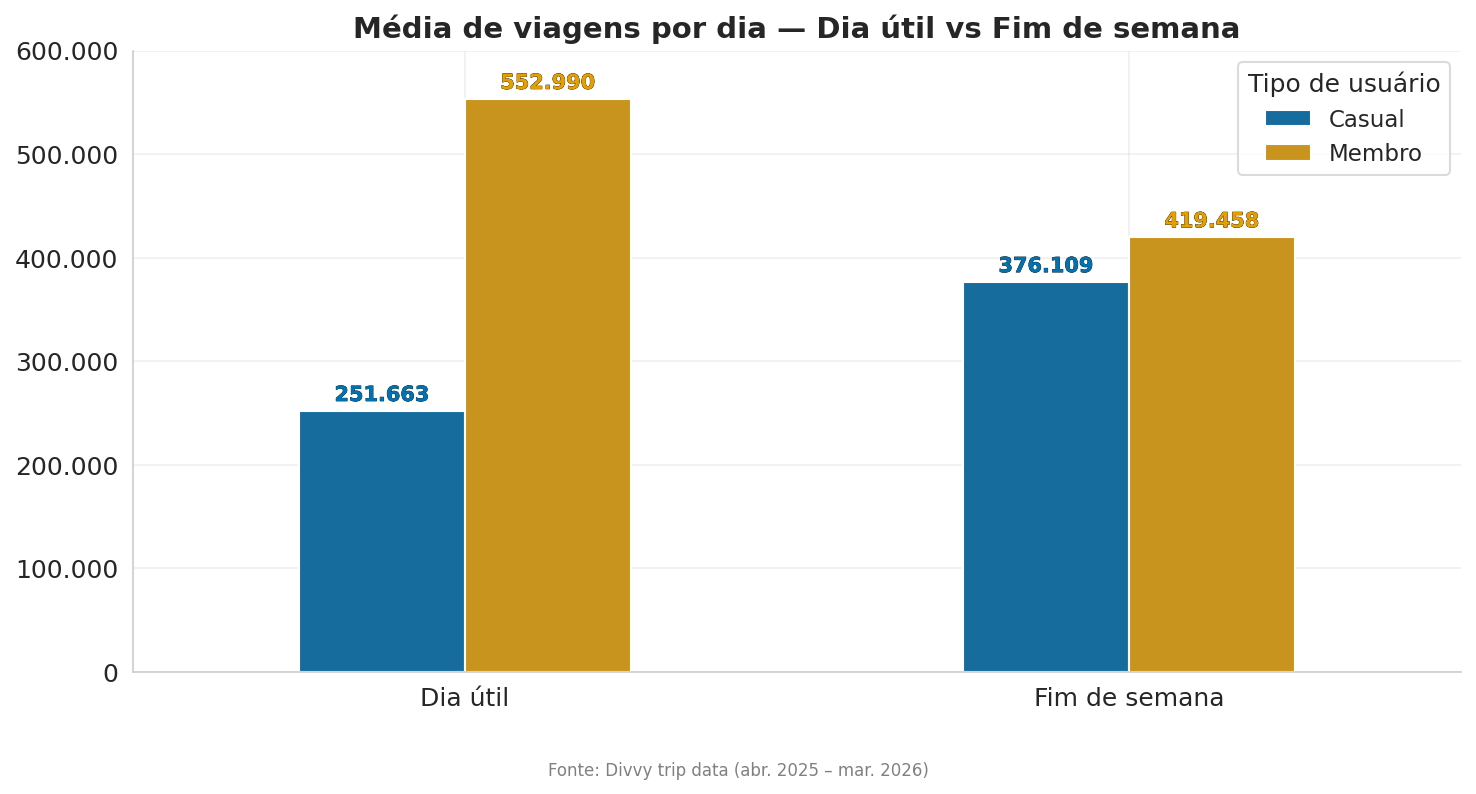

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=df_agrupamento, 
    x='Período', 
    y='Média de viagens por Dia', 
    hue='Usuário',
    palette=[COR_CASUAL, COR_MEMBER],
    ax=ax,
    order=['Dia útil', 'Fim de semana'],
    hue_order=['casual', 'member'],
    width=0.5
)

for container in ax.containers:
    for bar in container:
        yval = bar.get_height()
        cor_texto = COR_CASUAL if container == ax.containers[0] else COR_MEMBER
        
        ax.annotate(
            f'{int(yval):,}'.replace(',', '.'), 
            xy=(bar.get_x() + bar.get_width() / 2, yval),
            xytext=(0, 3),
            textcoords="offset points",
            ha='center', va='bottom',
            fontsize=10, fontweight='bold',
            color=cor_texto,
            path_effects=[path_effects.withStroke(linewidth=0.3, foreground='black')]
        )

ax.set_title('Média de viagens por dia — Dia útil vs Fim de semana')
ax.set_ylabel('')
ax.set_xlabel('', labelpad=12) 
ax.set_ylim(0, 600000)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.')))

ax.grid(alpha=0.3)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Casual', 'Membro'], title='Tipo de usuário', loc='upper right', frameon=True, edgecolor='lightgray')

sns.despine(top=True, right=True)

plt.figtext(0.5, -0.05, 'Fonte: Divvy trip data (abr. 2025 – mar. 2026)', ha='center', fontsize=8, color='gray')
plt.tight_layout()

caminho_grafico0 = os.path.join('..', 'assets', 'grafico0_media.png')
plt.savefig(caminho_grafico0, bbox_inches='tight')

plt.show()

**Resumo:** Casuais estão mais propensos a utilizar o serviço aos fins de semana.  
Ao passo que Membros tendem a utilizá-lo em dia útil.  

---

### 1.2 Volume de viagens por horário do dia

In [7]:
#Distribuição de viagens ao longo do dia - por grupo
df_hora = con.execute(""" 
    SELECT
        member_casual AS "Usuário",
        EXTRACT(HOUR FROM started_at) AS "Hora do Dia",
        COUNT(*) AS "Volume de viagens",
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(PARTITION BY member_casual), 2) AS "% do Grupo"
    FROM cyclistic
    GROUP BY 1, 2
    ORDER BY 1, 2
""").df()

display(df_hora)

,Usuário,Hora do Dia,Volume de viagens,% do Grupo
0,casual,0,39387,1.96
1,casual,1,25177,1.25
2,casual,2,16804,0.84
3,casual,3,9225,0.46
4,casual,4,7333,0.36
5,casual,5,11692,0.58
6,casual,6,26961,1.34
7,casual,7,50132,2.49
8,casual,8,71145,3.54
9,casual,9,70874,3.53


---
#### Traduzindo esses números em gráfico:

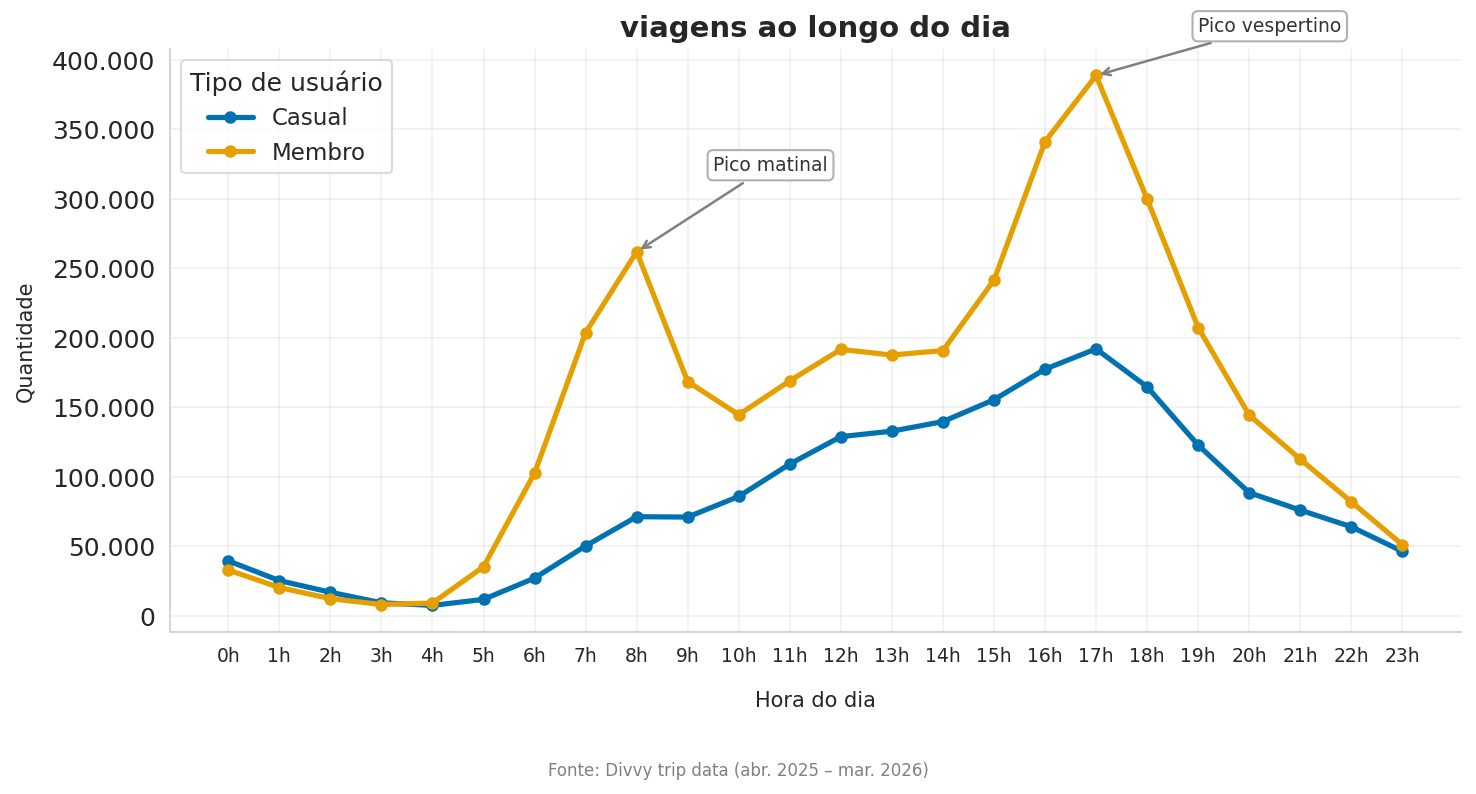

In [8]:
#Gráfico: viagens ao longo do dia
df_casual = df_hora[df_hora['Usuário'] == 'casual']
df_member = df_hora[df_hora['Usuário'] == 'member']

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_casual['Hora do Dia'], df_casual['Volume de viagens'],
        color=COR_CASUAL, marker='o', markersize=5, linewidth=2.5, label='Casual')
ax.plot(df_member['Hora do Dia'], df_member['Volume de viagens'],
        color=COR_MEMBER, marker='o', markersize=5, linewidth=2.5, label='Membro')

ax.annotate('Pico matinal',
            xy=(8, df_member[df_member['Hora do Dia'] == 8]['Volume de viagens'].values[0]),
            xytext=(9.5, 320000), fontsize=9, color='#333333',
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.2),
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='darkgray', alpha=0.9))
ax.annotate('Pico vespertino',
            xy=(17, df_member[df_member['Hora do Dia'] == 17]['Volume de viagens'].values[0]),
            xytext=(19, 420000), fontsize=9, color='#333333',
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.2),
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='darkgray', alpha=0.9))

ax.grid(alpha=0.3)
ax.set_xlabel('Hora do dia', fontsize=10, labelpad=12)
ax.set_ylabel('Quantidade', fontsize=10, labelpad=8)
ax.set_title('viagens ao longo do dia')
ax.set_xticks(range(0, 24))
ax.set_xticklabels([f'{h}h' for h in range(0, 24)], fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.')))

sns.despine(top=True, right=True)

ax.legend(title='Tipo de usuário', loc='upper left', frameon=True, edgecolor='lightgray')

plt.figtext(0.5, -0.05, 'Fonte: Divvy trip data (abr. 2025 – mar. 2026)', ha='center', fontsize=8, color='gray')
plt.tight_layout()

caminho_grafico1 = os.path.join('..', 'assets', 'grafico1_horario.png')
plt.savefig(caminho_grafico1, bbox_inches='tight')

plt.show()

**Análise da Seção 1:**  
Membros apresentam picos claros de uso às **8h e 17h**, coincidindo com os horários típicos de entrada e saída do trabalho. Casuais têm crescimento linear ao longo do dia, sem picos definidos.

Combinado com o que foi visto na seção 1.1, o padrão de membros aponta para **uso rotineiro e recorrente**. O padrão de casuais indica um **uso esporádico, sem horário fixo**.

---

## 2. Como cada grupo usa o serviço?
### Duração média de viagem

Duração de viagem é um indicador do *propósito* da viagem:  
- **viagens curtas e constantes** → sugerem uso com propósito definido (deslocamento, rotina)  
- **viagens longas e esporádicas** → rota flexível, foco no percurso em si

In [9]:
#Duração média de viagem - por grupo
con.execute("""
    SELECT
        member_casual AS "Usuário",
        ROUND(AVG(ride_duration_min), 2) AS "Duração Média (min)"
    FROM cyclistic
    GROUP BY 1
    ORDER BY 1
""").df()

,Usuário,Duração Média (min)
0,casual,19.05
1,member,12.01


In [10]:
#Duração média de viagem em cada dia da semana - por grupo
df_duracao = con.execute("""
    SELECT
        member_casual AS "Usuário",
        day_of_week AS "Dia da Semana",
        ROUND(AVG(ride_duration_min), 2) AS "Duração Média (min)"
    FROM cyclistic
    GROUP BY 1, 2
    ORDER BY 1, 2
""").df()

display(df_duracao)

,Usuário,Dia da Semana,Duração Média (min)
0,casual,0,22.03
1,casual,1,19.17
2,casual,2,16.70
3,casual,3,15.81
4,casual,4,16.73
5,casual,5,18.64
6,casual,6,21.35
7,member,0,13.21
8,member,1,11.72
9,member,2,11.62


---
#### Traduzindo os números em gráfico:

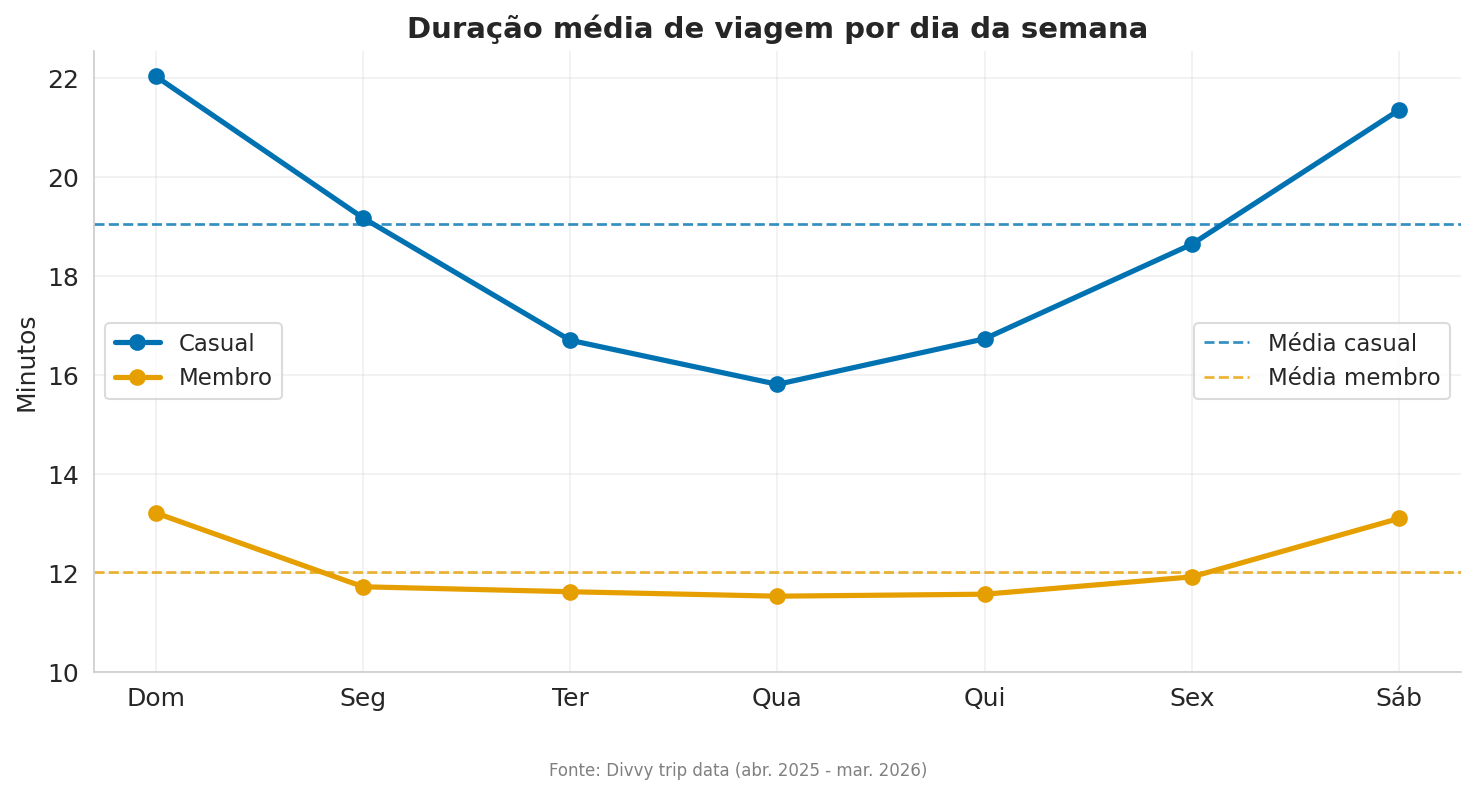

In [12]:
#Gráfico: duração média de viagem em cada dia da semana — por grupo
media_geral_df = con.execute("""
    SELECT member_casual AS "Usuário",
           ROUND(AVG(ride_duration_min), 2) AS "Duração Média (min)"
    FROM cyclistic
    GROUP BY 1
""").df()
media_casual = media_geral_df[media_geral_df['Usuário'] == 'casual']['Duração Média (min)'].values[0]
media_member = media_geral_df[media_geral_df['Usuário'] == 'member']['Duração Média (min)'].values[0]

casual_dur = df_duracao[df_duracao['Usuário'] == 'casual']
member_dur = df_duracao[df_duracao['Usuário'] == 'member']
dias_semana = ['Dom', 'Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb']

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(casual_dur['Dia da Semana'], casual_dur['Duração Média (min)'],
        color=COR_CASUAL, marker='o', markersize=7, linewidth=2.5, label='Casual')
ax.plot(member_dur['Dia da Semana'], member_dur['Duração Média (min)'],
        color=COR_MEMBER, marker='o', markersize=7, linewidth=2.5, label='Membro')

ax.axhline(media_casual, color=COR_CASUAL, linestyle='--', linewidth=1.3, alpha=0.8,
           label=f'Média casual')
ax.axhline(media_member, color=COR_MEMBER, linestyle='--', linewidth=1.3, alpha=0.8,
           label=f'Média membro')

ax.grid(alpha=0.3)
ax.set_ylabel('Minutos')
ax.set_title('Duração média de viagem por dia da semana')
ax.set_xticks(range(0, 7))
ax.set_xticklabels(dias_semana)
ax.set_ylim(bottom=10)

sns.despine(top=True, right=True)


handles, labels = ax.get_legend_handles_labels()


leg1 = ax.legend(handles[:2], labels[:2],
                 loc='center left', frameon=True, edgecolor='lightgray')
ax.add_artist(leg1)  

leg2 = ax.legend(handles[2:], labels[2:],
                 loc='center right', frameon=True, edgecolor='lightgray')

plt.figtext(0.5, -0.05, 'Fonte: Divvy trip data (abr. 2025 - mar. 2026)', ha='center', fontsize=8, color='gray')
plt.tight_layout()

caminho_grafico2 = os.path.join('..', 'assets', 'grafico2_semana.png')
plt.savefig(caminho_grafico2, bbox_inches='tight')

plt.show()

---
#### Validação com mediana  
A média comunica bem a diferença geral entre os grupos, mas a duração de uma viagem costuma ter o que chamamos de cauda longa: poucas viagens muito extensas podem elevar o valor médio de forma desproporcional.  
Por isso, adicionamos a mediana como métrica complementar. Ela representa melhor a viagem típica e ajuda a verificar se a diferença entre usuários casuais e membros permanece, mesmo reduzindo o efeito de viagens excepcionalmente longas.


In [13]:
#Media e mediana de duração de viagem - por grupo
df_duracao_resumo = con.execute("""
    SELECT
        member_casual AS "Usuario",
        ROUND(AVG(ride_duration_min), 2) AS "Media (min)",
        ROUND(MEDIAN(ride_duration_min), 2) AS "Mediana (min)"
    FROM cyclistic
    GROUP BY 1
    ORDER BY 1
""").df()

display(df_duracao_resumo)

,Usuario,Media (min),Mediana (min)
0,casual,19.05,11.34
1,member,12.01,8.58


#### Distribuição das durações  

Para visualizar o comportamento típico, limitamos o gráfico a viagens de até 60 minutos. Esse recorte evita que viagens muito longas comprimam a visualização e permite comparar onde a maior parte das viagens de cada grupo se concentra.


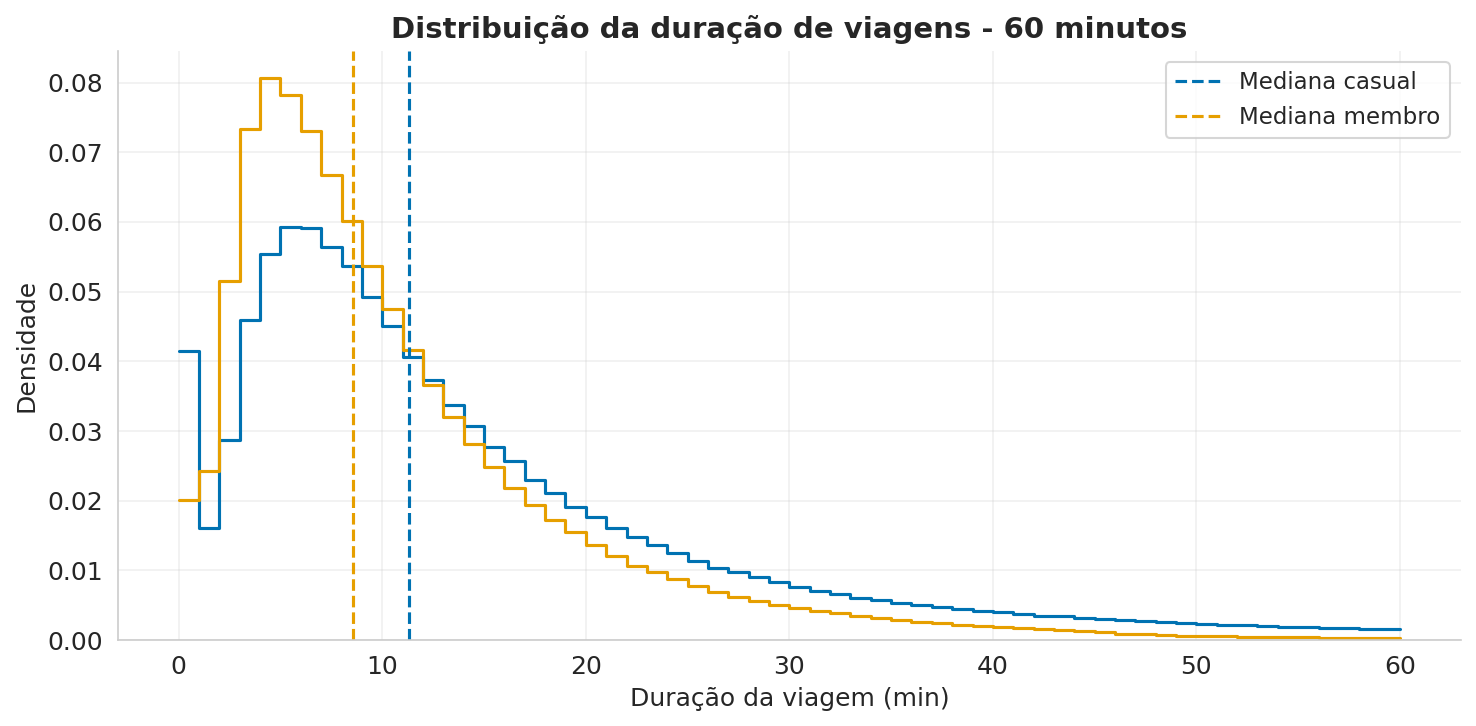

In [14]:
#Distribuição da duração das viagens até 60 minutos
df_duracao_dist = con.execute("""
    SELECT
        member_casual AS "Usuario",
        ride_duration_min AS "Duracao (min)"
    FROM cyclistic
    WHERE ride_duration_min <= 60
""").df()

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    data=df_duracao_dist,
    x='Duracao (min)',
    hue='Usuario',
    bins=60,
    stat='density',
    common_norm=False,
    element='step',
    fill=False,
    palette={'casual': COR_CASUAL, 'member': COR_MEMBER},
    ax=ax
)

ax.axvline(11.34, color=COR_CASUAL, linestyle='--', linewidth=1.5, label='Mediana casual')
ax.axvline(8.58, color=COR_MEMBER, linestyle='--', linewidth=1.5, label='Mediana membro')

ax.set_title('Distribuição da duração de viagens - 60 minutos')
ax.set_xlabel('Duração da viagem (min)')
ax.set_ylabel('Densidade')
ax.grid(alpha=0.3)
ax.legend()
sns.despine()

plt.tight_layout()
plt.show()


**Análise da Seção 2**  
Usuários casuais pedalam, em média, significativamente mais tempo do que os membros, e essa duração varia: quanto mais próximo do meio da semana, menor é o tempo de uso, com picos no fim de semana. Já os membros mantêm uma duração média quase constante todos os dias, com variação mínima.  

A mediana reforça essa leitura, mas apresenta uma distância menor entre os dois grupos (Membros: 8,58 minutos x Casuais: 11,34 minutos) o que indica que o valor médio dos casuais é ligeiramente inflado por viagens mais longas. Ainda assim, a tendência permanece: mesmo reduzindo o efeito de viagens excepcionalmente longas, casuais continuam realizando viagens mais extensas que membros.  

A distribuição de até 60 minutos complementa essa leitura ao mostrar a concentração das viagens mais comuns.  

Esse padrão reforça a ideia da seção anterior: membros possuem rotas fixas e previsíveis, enquanto casuais apresentam trajetos mais "livres" e longos. 

---


## 3. Contexto de uso: sazonalidade e localização

Agora analisamos **onde** e **em que época do ano** cada grupo usa o serviço.  
Essas duas dimensões revelam o *contexto* do uso — e se ele depende de fatores externos como clima e ambiente.

### 3.1 Sazonalidade — uso por estação do ano

Estações do ano em Chicago:  
- **Primavera:** 20/03 – 20/06  
- **Verão:** 21/06 – 21/09  
- **Outono:** 22/09 – 20/12  
- **Inverno:** 21/12 – 19/03
  
Obs: Datas aproximadas.

In [15]:
#Percentual de viagens em cada estação do ano - por grupo
df_estacao = con.execute("""
    SELECT
        member_casual AS "Usuário",
        CASE
            WHEN EXTRACT(MONTH FROM started_at) * 100 + EXTRACT(DAY   FROM started_at) BETWEEN  320 AND  620 THEN 'Primavera'
            WHEN EXTRACT(MONTH FROM started_at) * 100 + EXTRACT(DAY   FROM started_at) BETWEEN  621 AND  921 THEN 'Verão'
            WHEN EXTRACT(MONTH FROM started_at) * 100 + EXTRACT(DAY   FROM started_at) BETWEEN  922 AND 1220 THEN 'Outono'
            ELSE 'Inverno'
        END AS "Estação do Ano",
        COUNT(*) AS "Total de viagens",
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(PARTITION BY member_casual), 2) AS "% do Grupo"
    FROM cyclistic
    GROUP BY 1, 2
    ORDER BY 1, 2
""").df()

display(df_estacao)

,Usuário,Estação do Ano,Total de viagens,% do Grupo
0,casual,Inverno,114328,5.69
1,casual,Outono,421308,20.96
2,casual,Primavera,519675,25.85
3,casual,Verão,955223,47.51
4,member,Inverno,427133,11.85
5,member,Outono,903874,25.08
6,member,Primavera,939781,26.08
7,member,Verão,1333077,36.99


---
#### Traduzindo esses números em gráfico

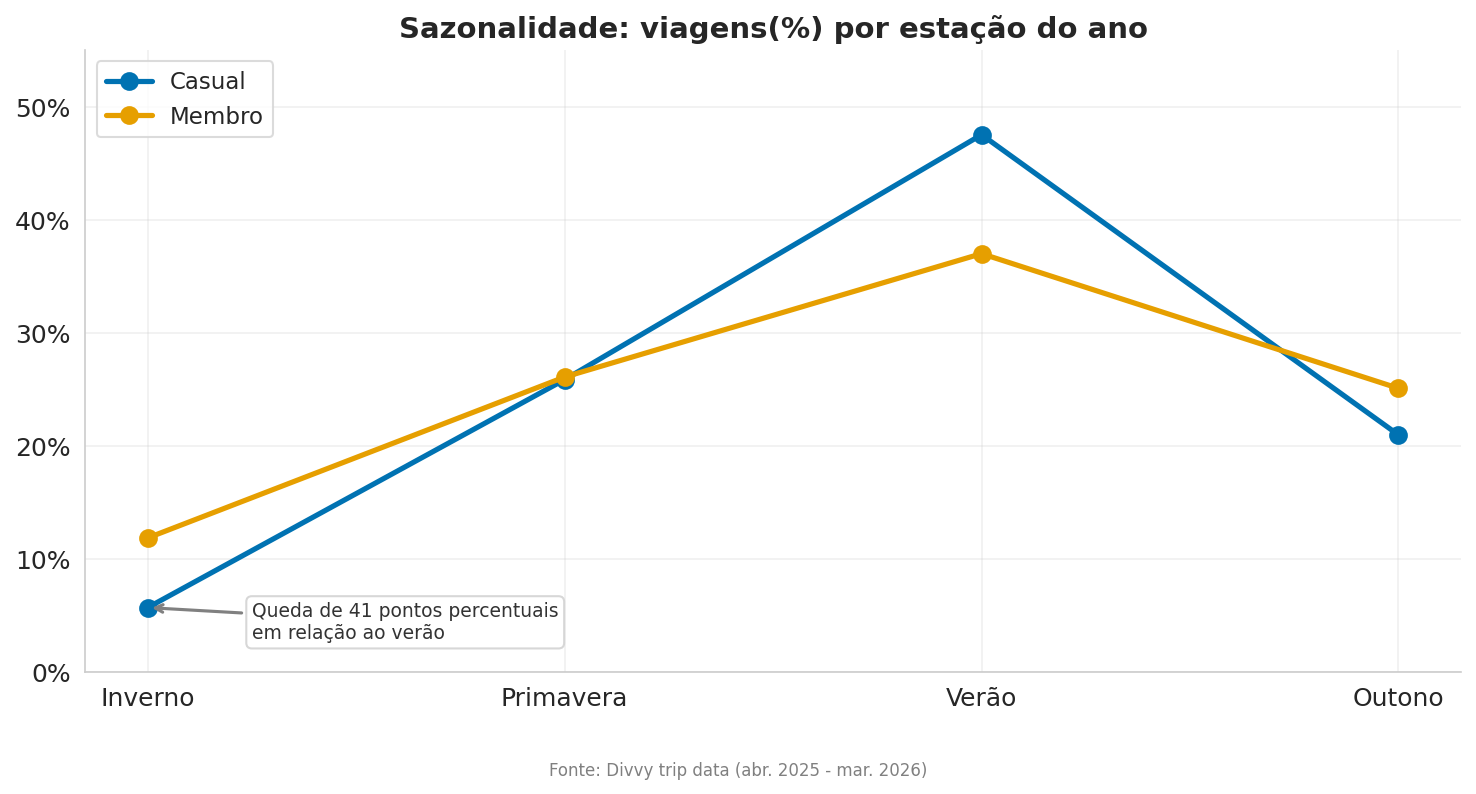

In [16]:
#Gráfico: viagens(%) em cada estação do ano — por grupo
ordem_estacao = ['Inverno', 'Primavera', 'Verão', 'Outono']
casual_est = df_estacao[df_estacao['Usuário'] == 'casual'].set_index('Estação do Ano')
member_est = df_estacao[df_estacao['Usuário'] == 'member'].set_index('Estação do Ano')

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(ordem_estacao, casual_est.loc[ordem_estacao, '% do Grupo'],
        color=COR_CASUAL, marker='o', markersize=8, linewidth=2.5, label='Casual')
ax.plot(ordem_estacao, member_est.loc[ordem_estacao, '% do Grupo'],
        color=COR_MEMBER, marker='o', markersize=8, linewidth=2.5, label='Membro')

ax.annotate('Queda de 41 pontos percentuais\nem relação ao verão',
            xy=('Inverno', casual_est.loc['Inverno', '% do Grupo']),
            xytext=(50, -15),               
            textcoords='offset points',     
            fontsize=9, ha='left', color='#333333',
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5),
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='lightgray', alpha=0.9))

ax.grid(alpha=0.3)
ax.set_title('Sazonalidade: viagens(%) por estação do ano')
ax.set_ylim(0, 55)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))

sns.despine(top=True, right=True)
ax.legend(loc='upper left', frameon=True, edgecolor='lightgray')
plt.figtext(0.5, -0.05, 'Fonte: Divvy trip data (abr. 2025 - mar. 2026)', ha='center', fontsize=8, color='gray')
plt.tight_layout()

caminho_grafico3 = os.path.join('..', 'assets', 'grafico3_sazonalidade.png')
plt.savefig(caminho_grafico3, bbox_inches='tight')

plt.show()

**Resumo:**  
Ambos os grupos reduzem o uso no inverno, mas a queda proporcional é muito maior entre casuais (41,8 pontos percentuais) do que entre membros (25 pontos percentuais). Casuais são significativamente mais sensíveis às variações climáticas, no que diz respeito ao uso do serviço.

Isso faz sentido dentro da hipótese de uso por lazer: **lazer depende do clima, deslocamento para o trabalho não.**  

>É válido ressaltar que o dataset em questão não nos fornece dados suficientes para que consigamos chegar em uma conclusão mais precisa a respeito dos motivadores por trás dessa diferença de redução nos dois grupos. Ficamos limitados às informações disponíveis.

### 3.2 Localização — estações de partida mais frequentes por grupo

> Essa análise considera apenas as estações da *início* de viagem. Registros com `start_station_name` nulo foram excluídos — esses nulos estão concentrados em bicicletas elétricas, que justificam os nulos pois podem ser travadas fora das estações fixas.

In [17]:
#Top 5 estações de partida - por grupo
con.execute("""
    (SELECT 'member' AS "Usuário", start_station_name AS "Estação", COUNT(*) AS "viagens"
     FROM cyclistic
     WHERE start_station_name IS NOT NULL AND member_casual = 'member'
     GROUP BY start_station_name
     ORDER BY COUNT(*) DESC
     LIMIT 5)
    UNION ALL
    (SELECT 'casual' AS "Usuário", start_station_name AS "Estação", COUNT(*) AS "viagens"
     FROM cyclistic
     WHERE start_station_name IS NOT NULL AND member_casual = 'casual'
     GROUP BY start_station_name
     ORDER BY COUNT(*) DESC
     LIMIT 5)
    ORDER BY "Usuário", "viagens" DESC
""").df()

,Usuário,Estação,viagens
0,casual,DuSable Lake Shore Dr & Monroe St,31300
1,casual,Navy Pier,29966
2,casual,Michigan Ave & Oak St,22382
3,casual,Streeter Dr & Grand Ave,21349
4,casual,DuSable Lake Shore Dr & North Blvd,19479
5,member,Kingsbury St & Kinzie St,25872
6,member,Clinton St & Washington Blvd,23561
7,member,Canal St & Madison St,22461
8,member,Clinton St & Madison St,21216
9,member,State St & Chicago Ave,19561


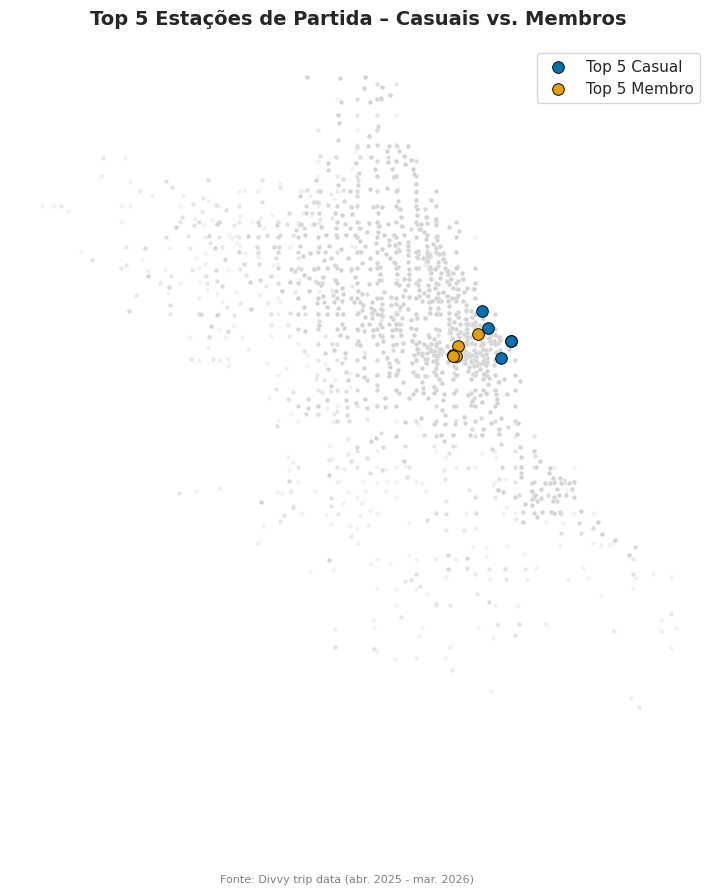

In [19]:
df_top_stations = con.execute("""
    (SELECT 'member' AS "Usuário", start_station_name AS "Estação", COUNT(*) AS "viagens",
            AVG(start_lat) AS start_lat, AVG(start_lng) AS start_lng
     FROM cyclistic
     WHERE start_station_name IS NOT NULL AND member_casual = 'member'
     GROUP BY start_station_name
     ORDER BY COUNT(*) DESC
     LIMIT 5)
    UNION ALL
    (SELECT 'casual' AS "Usuário", start_station_name AS "Estação", COUNT(*) AS "viagens",
            AVG(start_lat) AS start_lat, AVG(start_lng) AS start_lng
     FROM cyclistic
     WHERE start_station_name IS NOT NULL AND member_casual = 'casual'
     GROUP BY start_station_name
     ORDER BY COUNT(*) DESC
     LIMIT 5)
    ORDER BY "Usuário", "viagens" DESC
""").df()

df_fundo = con.execute("SELECT start_lng, start_lat FROM cyclistic USING SAMPLE 1%").df()
fig, ax = plt.subplots(figsize=(9, 9), dpi=100)

sns.scatterplot(data=df_fundo, x='start_lng', y='start_lat', 
                color='lightgray', alpha=0.3, s=10, ax=ax, legend=False)

sns.scatterplot(data=df_top_stations[df_top_stations['Usuário'] == 'casual'], 
                x='start_lng', y='start_lat', 
                color=COR_CASUAL, s=70, edgecolor='black', ax=ax, label='Top 5 Casual')

sns.scatterplot(data=df_top_stations[df_top_stations['Usuário'] == 'member'], 
                x='start_lng', y='start_lat', 
                color=COR_MEMBER, s=70, edgecolor='black', ax=ax, label='Top 5 Membro')

ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')
sns.despine(left=True, bottom=True)

ax.set_title(
    'Top 5 Estações de Partida – Casuais vs. Membros',
    fontsize=14,
    fontweight='bold',
    pad=15
)
plt.figtext(0.5, -0.05, 'Fonte: Divvy trip data (abr. 2025 - mar. 2026)', ha='center', fontsize=8, color='gray')
caminho_mapa = os.path.join('..', 'assets', 'grafico5_heatmap.png')
plt.savefig(caminho_mapa, bbox_inches='tight', dpi=150)
plt.show()

>Com o mapa de calor fica mais visível a preferência de usuários casuais pela orla de michigan, em contraste com uma concentração mais "para dentro" da cidade que retrata as principais estações usadas pelos Membros.

**Resumo:**  
As estações mais usadas pelos dois grupos estão localizadas em setores diferentes da cidade de Chicago:

- **Membros** partem de regiões como Clinton St, Canal St e Kingsbury St — área central de Chicago (conhecida como Downtown), núcleo urbano e comercial da cidade.
- **Casuais** partem de DuSable Lake Shore Dr, Navy Pier, Streeter Dr e Michigan Ave — orla do Lago Michigan (conhecida como Lakefront), regiões de parques, praias e atrações turísticas.

O perfil presente nessas localizações confirma o comportamento observado nas seções anteriores.

**Análise da Seção 3:**  
Casuais são mais sensíveis à sazonalidade climática, dado o propósito do seu uso, e partem de áreas associadas a lazer e turismo.  
Membros são menos afetados por mudanças climáticas, no que diz respeito ao uso do serviço, e partem de zonas com alta densidade urbana e movimento comercial.

---

## 4. O que não diferencia os grupos
### Tipo de bicicleta

Testamos se a preferência de tipo de bicicleta difere entre os grupos.

In [20]:
#Distribuição de tipo de bicicleta - por grupo
con.execute("""
    SELECT
        member_casual AS "Usuário",
        rideable_type AS "Tipo de Bicicleta",
        COUNT(*) AS "Total",
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(PARTITION BY member_casual), 2) AS "% do Grupo"
    FROM cyclistic
    GROUP BY 1, 2
    ORDER BY 1, 2
""").df()

,Usuário,Tipo de Bicicleta,Total,% do Grupo
0,casual,classic_bike,663688,33.01
1,casual,electric_bike,1346846,66.99
2,member,classic_bike,1271928,35.29
3,member,electric_bike,2331937,64.71


**Análise da Seção 4:**  
A preferência por tipo de bicicleta é essencialmente igual entre os grupos (64-66% e-bike, 33-35% clássica). **Estes dados não demonstram quaisquer impactos na diferenciação entre casuais e membros**.

---

## 5. Conclusão e Recomendações

### Resumo dos achados

As quatro seções analisadas convergem para um mesmo ponto central:

| Dimensão | Membros | Casuais |
|---|---|---|
| **Quando** | Dias úteis · picos às 8h e 17h | Fins de semana · crescimento gradual ao longo do dia |
| **Como** | viagens curtas e recorrentes (12 min) | viagens longas e esporádicas (19 min) |
| **Contexto** | Queda moderada no inverno | Queda acentuada no inverno |
| **Onde** | Downtown · área de maior densidade urbana e comercial da cidade | Lakefront · parques, praias e atrações turísticas |

**A diferença fundamental entre os grupos é o propósito da viagem.**  
Membros anuais usam o serviço para **deslocamento fixo e recorrente**
Usuários casuais usam o serviço para **lazer** — viagens, turismo e situações pontuais.

---

### Recomendações

>As recomendações abaixo são orientadas por padrões de uso e devem ser validadas com dados financeiros internos, como margem por plano, custo de aquisição, taxa de conversão e valor vitalício do cliente.  

**Recomendação 1 — Campanhas de conversão orientadas pelo comportamento natural do casual**  
*Baseada em:* Usuários casuais já são clientes ativos da Cyclistic — não são prospects frios. Eles conhecem o serviço e o escolhem. A análise de localização mostra que seu uso se concentra em um conjunto específico de estações: DuSable Lake Shore Dr & Monroe St, Navy Pier, Michigan Ave & Oak St, Streeter Dr & Grand Ave e DuSable Lake Shore Dr & North Blvd — todas na orla do Lago Michigan. Além disso, casuais percorrem em média 19 minutos por viagem, contra 12 minutos dos membros, indicando alto engajamento com o serviço quando o utilizam. A barreira não aparenta ser desconhecimento ou desinteresse — e sim a ausência de um incentivo que torne a conversão financeiramente racional.  
A Cyclistic deve lançar campanhas de conversão concentradas fisicamente nas estações de maior volume casual do Lakefront, com um mecanismo de desconto progressivo vinculado à frequência de uso. A lógica é simples: cada corrida acumula crédito em direção a um desconto na adesão ao plano anual. O usuário não precisa mudar seu comportamento — ele é recompensado exatamente pelo que já faz. Os mecanismos de engajamento — desafios semanais via app, metas de minutos pedalados, número de corridas em um período — ficam a cargo do time de marketing, que definirá os formatos mais adequados às diretrizes da empresa. O princípio central é usar o comportamento existente do casual como motor da conversão, em vez de tentar criar um comportamento novo.

---

**Recomendação 2 — Segmentação do plano anual em modalidades sazonais**  
*Baseada em:* Casuais concentram 47,51% de suas viagens no verão e apenas 5,69% no inverno — uma queda proporcional de 41,8 pontos percentuais entre o pico e a baixa temporada. Membros, em contraste, reduzem apenas 25 pontos percentuais no mesmo período. Essa diferença indica que o inverno representa um período de baixo valor percebido para o casual: o plano anual exige pagamento por 12 meses, mas o casual usa ativamente o serviço por aproximadamente 8 ou 9. Frente à alternativa de passes avulsos, o plano anual se torna uma decisão financeiramente desfavorável — não por falta de interesse no serviço, mas pela estrutura do produto.  
A Cyclistic deve criar modalidades de plano com duração flexível, cobrindo os períodos de maior uso casual — Primavera, Verão e Outono. Exemplos ilustrativos de segmentação: Plano Primavera-Verão, Plano Verão-Outono, Plano Primavera-Verão-Outono. Os nomes, períodos exatos e precificação são definições do departamento de marketing, alinhadas às diretrizes e margens da empresa. O ponto central é que esse produto não substitui o plano anual — ele cria uma escada de valor. Um usuário que adere a um plano de 6 ou 8 meses experimenta os benefícios de ser membro e tem uma trajetória de conversão ao plano anual muito mais natural do que aquele que segue comprando passes avulsos indefinidamente. A barreira do inverno é removida, e a decisão de assinar deixa de ser um risco financeiro para se tornar algo racionalmente justificável para o casual.

---

**Recomendação 3 — Conversão digital no momento de maior engajamento**  
*Baseada em:* Casuais concentram 47,51% de suas viagens no verão e 59% de sua média diária nos fins de semana — os dois picos coincidem: o casual de verão, no fim de semana, no Lakefront, é o casual mais engajado com o serviço que existe. É também o momento em que ele sente na prática o que significa usar a Cyclistic com frequência. A barreira à conversão não é falta de experiência com o produto — é a ausência de um gatilho que torne o custo-benefício da assinatura visível e imediato no momento certo.  
A Cyclistic deve desenvolver uma estratégia de conversão digital direcionada especificamente aos momentos de pico de uso casual — verão e fins de semana — explorando o canal do aplicativo para apresentar a proposta de valor da assinatura com base no histórico real de uso de cada usuário. O argumento de conversão não é genérico: é pessoal e calculado. Uma comunicação contextual — durante ou após uma corrida, nesse período — pode mostrar ao usuário quanto ele já gastou em passes avulsos na temporada, e quanto teria pago com um plano. A comparação emerge do próprio comportamento do casual, sem abstração. O formato exato das comunicações, os critérios de segmentação e os canais digitais complementares — redes sociais, e-mail, notificações — ficam a cargo do time de marketing e da equipe de produto, alinhados às diretrizes da empresa. O princípio central é simples: o melhor momento para converter um casual é aquele em que ele está maximizando o valor do serviço e pode ver isso com clareza.